# PCA network visualization with Yeo-7 overlap

This notebook creates a clean final version of the analysis for:

1. selecting the top 4 PCA components,
2. plotting thresholded glass-brain maps with one shared colorbar,
3. overlaying Yeo-7 networks within each PCA component, and
4. saving a summary overlap CSV.

## Outputs
- Top-4 PCA glass-brain figure (`.png`, `.pdf`)
- Yeo-7 atlas reference figure (`.png`, `.pdf`)
- One Yeo-7 overlay figure per selected PCA component (`.png`, `.pdf`)
- Overlap table (`.csv`) with percent voxel and percent absolute-weight overlap

## Before you run
Update the paths in the configuration cell if your project folder changes.


## 1. Configuration

Edit only this cell for routine changes such as the project path, selected `K`, threshold level, or whether to auto-read the top PCs from a CSV.


In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import ListedColormap
from nilearn import datasets, plotting
from nilearn.image import index_img, load_img, new_img_like, resample_to_img
from scipy.ndimage import binary_erosion

# ------------------------------
# User settings
# ------------------------------
ROOT = Path("/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2")
K = 20

PCA_NIFTI = ROOT / f"group_pca_K{K}_components.nii.gz"
OUTDIR = ROOT / "paper_figures_partB_pca_yeo7"
OUTDIR.mkdir(parents=True, exist_ok=True)

# Top component selection
USE_AUTO_TOP4 = True
TOP_PCS_1BASED_MANUAL = [7, 9, 10, 11]
AUTO_TOP4_CSV = ROOT / f"step3_topm4_plus_nested_sensitivity/main_fixed_topm4_K{K}_pcsets.csv"

# Visualization / preprocessing knobs
ERODE_ITERS = 1
KEEP_TOP_PCT = 20.0      # keep strongest 20% of |PC| values inside eroded brain mask
SHARED_VMAX_PCT = 99.0   # lower => brighter maps
PCA_CMAP = "YlOrBr"
GLASS_DISPLAY_MODE = "lyrz"
DPI = 600

print("Project root:", ROOT)
print("PCA NIfTI:", PCA_NIFTI)
print("Output directory:", OUTDIR)
print("Auto top-4 enabled:", USE_AUTO_TOP4)


Project root: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2
PCA NIfTI: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/group_pca_K20_components.nii.gz
Output directory: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/paper_figures_partB_pca_yeo7
Auto top-4 enabled: True


## 2. Helper functions

These helpers keep the notebook readable by separating component selection, resampling, thresholding, and overlap calculations.


In [2]:
def maybe_load_auto_top4(csv_path: Path):
    """Try to infer a list of four 1-based PC indices from a CSV file."""
    if not csv_path.exists():
        return None

    df = pd.read_csv(csv_path)

    # Case 1: object column with something like '(7, 9, 10, 11)' or 'PC7,PC9,PC10,PC11'
    for col in df.columns:
        if df[col].dtype == object and len(df[col]) > 0:
            text = str(df[col].iloc[0])
            cleaned = "".join(ch if (ch.isdigit() or ch == ",") else " " for ch in text)
            cleaned = cleaned.replace(" ", "")
            values = [p for p in cleaned.split(",") if p]
            nums = [int(v) for v in values if v.isdigit()]
            if len(nums) >= 4:
                return nums[:4]

    # Case 2: explicit pc1..pc4 columns
    pc_cols = [c for c in df.columns if c.lower() in {"pc1", "pc2", "pc3", "pc4"}]
    if len(pc_cols) == 4:
        return [int(df[c].iloc[0]) for c in pc_cols]

    return None


def resample_to_mni(img_3d, mni_template):
    return resample_to_img(img_3d, mni_template, interpolation="continuous")


def abs_inside_mask(img_mni, mask_bool, reference_img):
    """Return |img| inside mask and 0 outside."""
    data = img_mni.get_fdata()
    out = np.zeros_like(data, dtype=np.float32)
    inside = mask_bool & np.isfinite(data)
    out[inside] = np.abs(data[inside]).astype(np.float32)
    return new_img_like(reference_img, out)


def threshold_keep_top_pct(abs_img_mni, mask_bool, keep_top_pct, reference_img):
    """Keep only the top X percent of positive values inside the mask."""
    data = abs_img_mni.get_fdata()
    values = data[mask_bool]
    values = values[np.isfinite(values)]
    values = values[values > 0]

    if values.size == 0:
        return abs_img_mni, 0.0

    threshold = float(np.percentile(values, 100.0 - keep_top_pct))

    out = np.zeros_like(data, dtype=np.float32)
    inside = mask_bool & np.isfinite(data)
    out[inside] = data[inside]
    out[out < threshold] = 0.0
    return new_img_like(reference_img, out), threshold


def robust_shared_vmax(abs_imgs_mni, mask_bool, pct):
    """Compute one shared vmax from all positive inside-mask values across images."""
    all_values = []
    for img in abs_imgs_mni:
        data = img.get_fdata()
        values = data[mask_bool]
        values = values[np.isfinite(values)]
        values = values[values > 0]
        if values.size:
            all_values.append(values)

    if not all_values:
        return 1e-6

    all_values = np.concatenate(all_values)
    return float(np.percentile(all_values, pct))


def active_mask_from_abs_thr(abs_thr_img, mask_bool):
    data = abs_thr_img.get_fdata()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    active_mask = (data > 0) & mask_bool
    return active_mask, data


def yeo7_overlap_table_for_pc(abs_thr_img, mask_bool, yeo_labels, pc_label, thr_abs_used, keep_top_pct, yeo_names):
    """Compute weighted and voxel overlap of one PC with Yeo-7 labels."""
    active_mask, data = active_mask_from_abs_thr(abs_thr_img, mask_bool)
    active_net = active_mask & (yeo_labels > 0)

    denom_weight = float(np.sum(data[active_mask]))
    denom_voxels = int(np.sum(active_net))

    rows = []
    for net_id in range(1, 8):
        netmask = active_mask & (yeo_labels == net_id)
        sum_weight = float(np.sum(data[netmask]))
        n_voxels = int(np.sum(netmask))

        pct_weight = 0.0 if denom_weight <= 0 else 100.0 * sum_weight / denom_weight
        pct_voxels = 0.0 if denom_voxels <= 0 else 100.0 * n_voxels / denom_voxels

        rows.append({
            "pc": pc_label,
            "network_id": net_id,
            "network_name": yeo_names[net_id],
            "percent_abs_weight": pct_weight,
            "percent_voxels": pct_voxels,
            "sum_abs_weight": sum_weight,
            "n_voxels": n_voxels,
            "top_pct_kept": float(keep_top_pct),
            "thr_abs_used": float(thr_abs_used),
        })

    return pd.DataFrame(rows)


def add_legend_row(ax_leg, handles, ncol=4, fontsize=10):
    """Place legend in a dedicated subplot so it never covers the brain plots."""
    ax_leg.set_axis_off()
    ax_leg.legend(
        handles=handles,
        loc="center",
        ncol=ncol,
        frameon=False,
        fontsize=fontsize,
        handlelength=1.2,
        columnspacing=1.2,
    )


## 3. Load PCA data, choose components, and prepare thresholded maps

This cell loads the PCA component image, creates the eroded MNI mask, selects the top 4 components, and builds thresholded absolute-value maps for plotting.


In [3]:
# Load PCA image and MNI template
print("Loading PCA image:", PCA_NIFTI)
pca_img = load_img(str(PCA_NIFTI))
print("PCA image shape:", pca_img.shape)

mni = datasets.load_mni152_template(resolution=2)
mni_mask = datasets.load_mni152_brain_mask(resolution=2).get_fdata().astype(bool)
mask_eroded = binary_erosion(mni_mask, iterations=ERODE_ITERS)

print(f"MNI mask voxels: {mni_mask.sum():,}")
print(f"Eroded mask voxels (iters={ERODE_ITERS}): {mask_eroded.sum():,}")

# Choose top 4 PCs
if USE_AUTO_TOP4:
    auto_top4 = maybe_load_auto_top4(AUTO_TOP4_CSV)
    if auto_top4 is not None:
        TOP_PCS_1BASED = auto_top4
        print(f"[Auto] Using top-4 PCs from {AUTO_TOP4_CSV.name}: {TOP_PCS_1BASED}")
    else:
        TOP_PCS_1BASED = TOP_PCS_1BASED_MANUAL
        print("[Auto] Could not parse auto CSV. Falling back to manual PCs:", TOP_PCS_1BASED)
else:
    TOP_PCS_1BASED = TOP_PCS_1BASED_MANUAL
    print("Using manual PCs:", TOP_PCS_1BASED)

top_idx0 = [pc - 1 for pc in TOP_PCS_1BASED]

# Build thresholded absolute maps and shared vmax
abs_thr_imgs = []
thresholds_used = {}

for pc1, idx0 in zip(TOP_PCS_1BASED, top_idx0):
    component_img = index_img(pca_img, idx0)
    component_mni = resample_to_mni(component_img, mni)
    component_abs = abs_inside_mask(component_mni, mask_eroded, mni)
    component_abs_thr, threshold = threshold_keep_top_pct(
        component_abs,
        mask_eroded,
        KEEP_TOP_PCT,
        mni,
    )
    abs_thr_imgs.append(component_abs_thr)
    thresholds_used[pc1] = threshold

shared_vmax = robust_shared_vmax(abs_thr_imgs, mask_eroded, SHARED_VMAX_PCT)

summary_df = pd.DataFrame({
    "pc": [f"PC{pc:02d}" for pc in TOP_PCS_1BASED],
    "threshold_abs": [thresholds_used[pc] for pc in TOP_PCS_1BASED],
})

print("Shared vmax:", shared_vmax)
display(summary_df.round(6))


Loading PCA image: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/group_pca_K20_components.nii.gz
PCA image shape: (91, 109, 91, 20)
MNI mask voxels: 235,375
Eroded mask voxels (iters=1): 217,621
[Auto] Using top-4 PCs from main_fixed_topm4_K20_pcsets.csv: [7, 9, 10, 11]
Shared vmax: 0.0035552841168828356


,pc,threshold_abs
0,PC07,0.000482
1,PC09,0.001055
2,PC10,0.000766
3,PC11,0.000839


## 4. Plot the final top-4 PCA glass-brain figure

Each row shows one thresholded PCA component. Labels are placed in a separate column to keep the brain panels clean.


/var/folders/t5/2x7db7gn5cvcnqkt970hp7hc0000gn/T/ipykernel_28370/2334228327.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


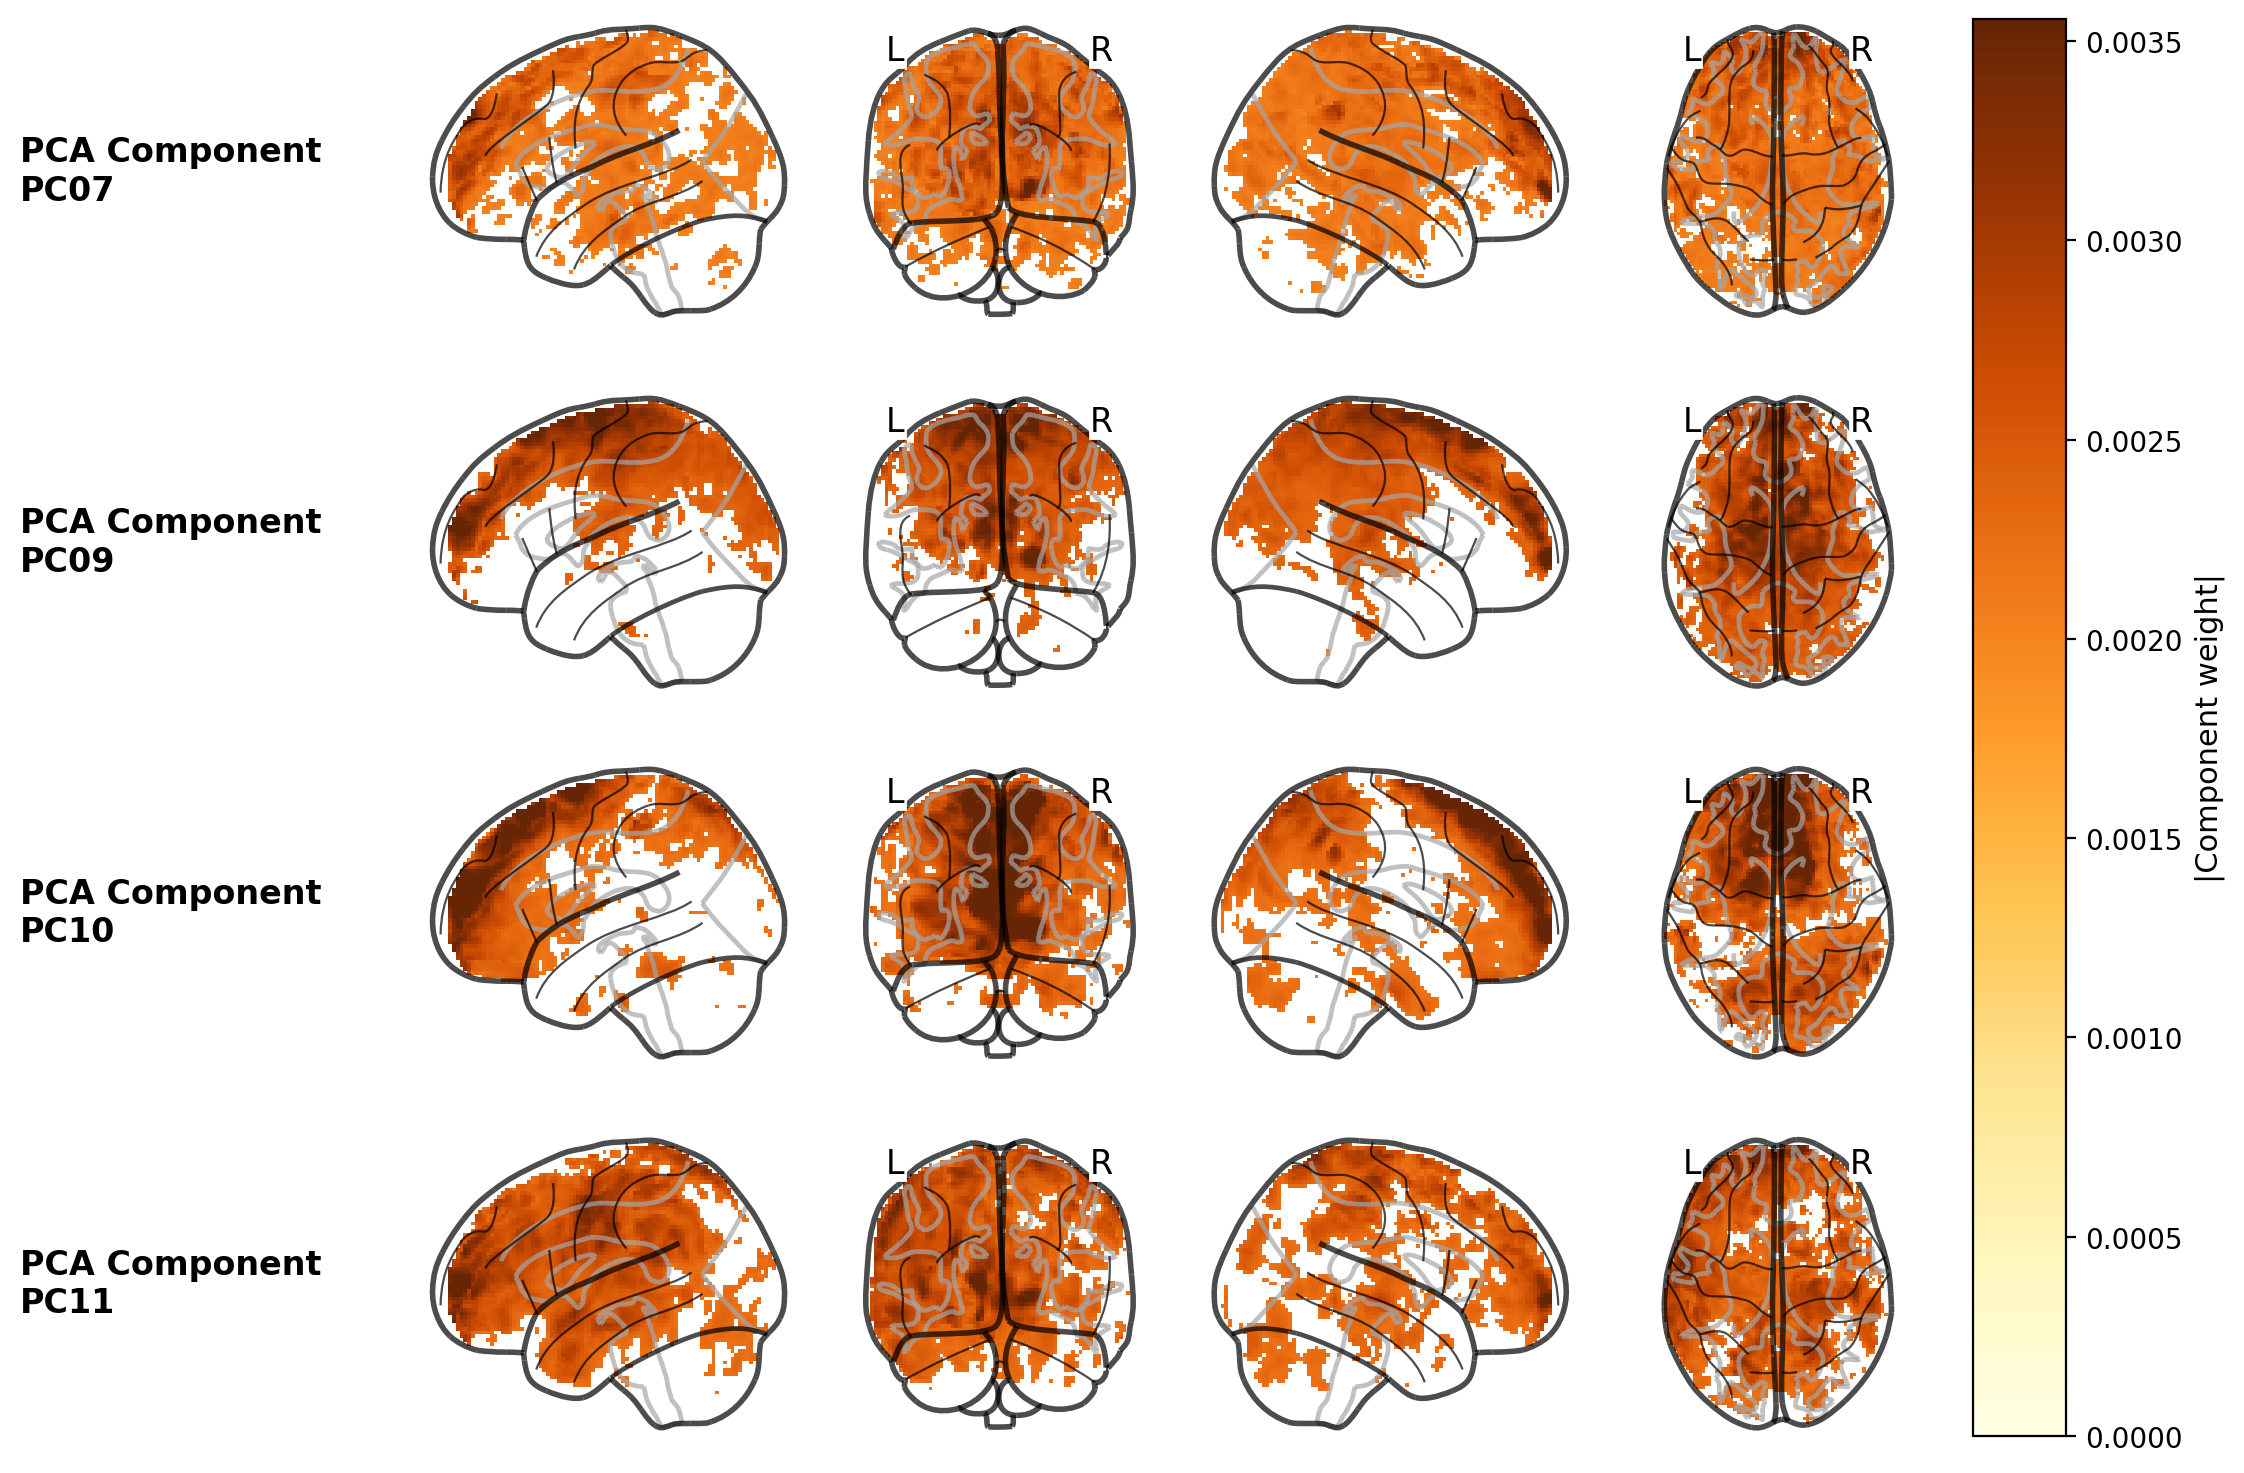

Saved PCA glass-brain figure:
 - /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/paper_figures_partB_pca_yeo7/Top4PCs_glass_noBG_sharedCbar_TOP20pct_K20.png
 - /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/paper_figures_partB_pca_yeo7/Top4PCs_glass_noBG_sharedCbar_TOP20pct_K20.pdf


In [4]:
nrows = len(abs_thr_imgs)

fig = plt.figure(figsize=(13.2, 2.3 * nrows), dpi=200)
gs = fig.add_gridspec(
    nrows=nrows,
    ncols=3,
    width_ratios=[0.22, 1.0, 0.06],
    wspace=0.04,
    hspace=0.22,
)

for row_idx, (pc1, img_abs_thr) in enumerate(zip(TOP_PCS_1BASED, abs_thr_imgs)):
    ax_label = fig.add_subplot(gs[row_idx, 0])
    ax_label.set_axis_off()
    ax_label.text(
        0.0,
        0.5,
        f"PCA Component\nPC{pc1:02d}",
        ha="left",
        va="center",
        fontsize=12,
        fontweight="bold",
    )

    ax_plot = fig.add_subplot(gs[row_idx, 1])
    plotting.plot_glass_brain(
        img_abs_thr,
        display_mode=GLASS_DISPLAY_MODE,
        cmap=PCA_CMAP,
        vmax=shared_vmax,
        colorbar=False,
        black_bg=False,
        plot_abs=True,
        axes=ax_plot,
        title=None,
    )

cax = fig.add_subplot(gs[:, 2])
norm = mpl.colors.Normalize(vmin=0, vmax=shared_vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps.get_cmap(PCA_CMAP))
sm.set_array([])
colorbar = fig.colorbar(sm, cax=cax)
colorbar.set_label("|Component weight|", fontsize=11)

fig.tight_layout()

out_png = OUTDIR / f"Top4PCs_glass_noBG_sharedCbar_TOP{int(KEEP_TOP_PCT)}pct_K{K}.png"
out_pdf = OUTDIR / f"Top4PCs_glass_noBG_sharedCbar_TOP{int(KEEP_TOP_PCT)}pct_K{K}.pdf"
fig.savefig(out_png, dpi=DPI, bbox_inches="tight", facecolor="white")
fig.savefig(out_pdf, dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved PCA glass-brain figure:")
print(" -", out_png)
print(" -", out_pdf)


## 5. Load Yeo-7 atlas and define plotting colors

The atlas is resampled to the MNI grid with nearest-neighbor interpolation so the label values remain intact.


In [5]:
YEO7_NAMES = {
    1: "Visual",
    2: "Somatomotor",
    3: "Dorsal Attention",
    4: "Ventral Attention / Salience",
    5: "Limbic",
    6: "Frontoparietal / Control",
    7: "Default Mode",
}

YEO7_COLORS = {
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#d62728",
    4: "#b2182b",
    5: "#9467bd",
    6: "#bcbd22",
    7: "#17becf",
}

handles = [
    mpatches.Patch(color=YEO7_COLORS[i], label=YEO7_NAMES[i])
    for i in range(1, 8)
]

yeo_colors_list = ["#ffffff"] + [YEO7_COLORS[i] for i in range(1, 8)]
cmap_yeo = ListedColormap(yeo_colors_list)

yeo = datasets.fetch_atlas_yeo_2011()
yeo7_img = load_img(yeo.thin_7)
yeo7_mni_img = resample_to_img(yeo7_img, mni, interpolation="nearest")
yeo_data = np.squeeze(yeo7_mni_img.get_fdata()).astype(np.int16)

assert yeo_data.shape == mask_eroded.shape, (
    f"Yeo shape {yeo_data.shape} does not match mask shape {mask_eroded.shape}"
)

print("Yeo atlas loaded and resampled successfully.")


Yeo atlas loaded and resampled successfully.


## 6. Plot the Yeo-7 atlas reference and per-component overlays

This cell saves:
- a standalone Yeo-7 atlas figure,
- one overlay figure for each selected PCA component, and
- a CSV summarizing overlap values.


/var/folders/t5/2x7db7gn5cvcnqkt970hp7hc0000gn/T/ipykernel_28370/2724928100.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


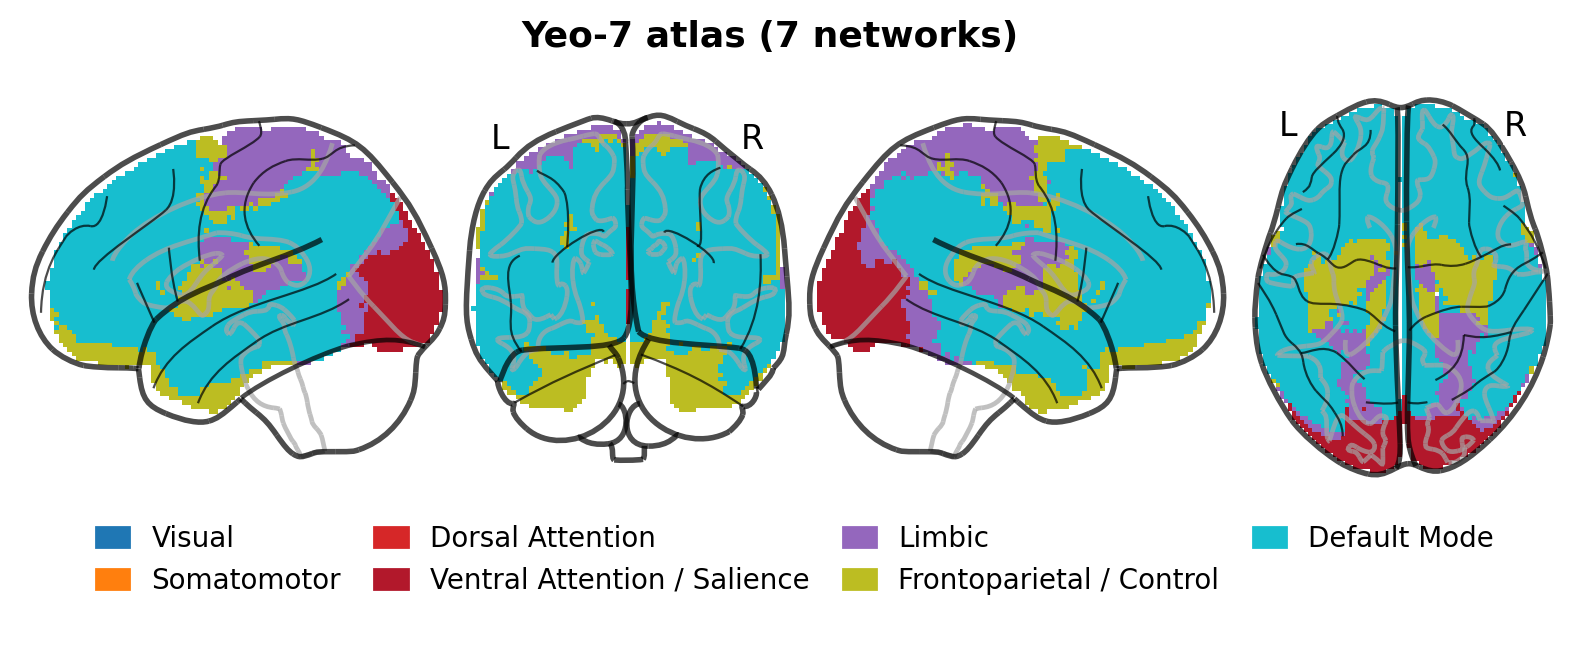

Saved Yeo atlas figure:
 - /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/paper_figures_partB_pca_yeo7/Yeo7_atlas_glass_customColors.png
 - /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/paper_figures_partB_pca_yeo7/Yeo7_atlas_glass_customColors.pdf


/var/folders/t5/2x7db7gn5cvcnqkt970hp7hc0000gn/T/ipykernel_28370/2724928100.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


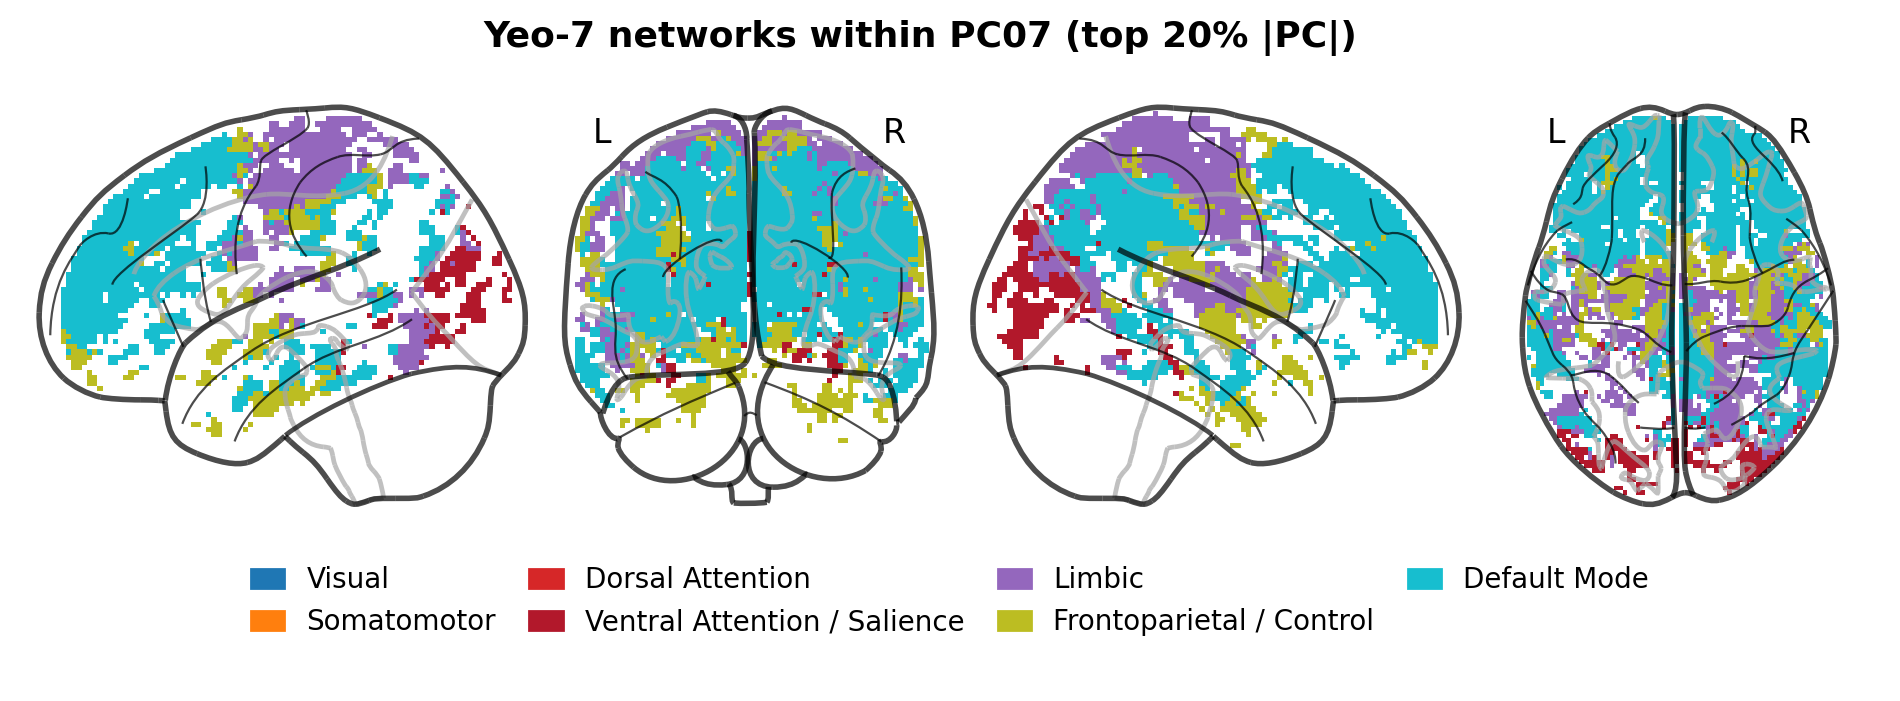

Saved overlay for PC07:
 - /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/paper_figures_partB_pca_yeo7/PC07_Yeo7Overlay_glass_TOP20pct_K20.png
 - /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/paper_figures_partB_pca_yeo7/PC07_Yeo7Overlay_glass_TOP20pct_K20.pdf


/var/folders/t5/2x7db7gn5cvcnqkt970hp7hc0000gn/T/ipykernel_28370/2724928100.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


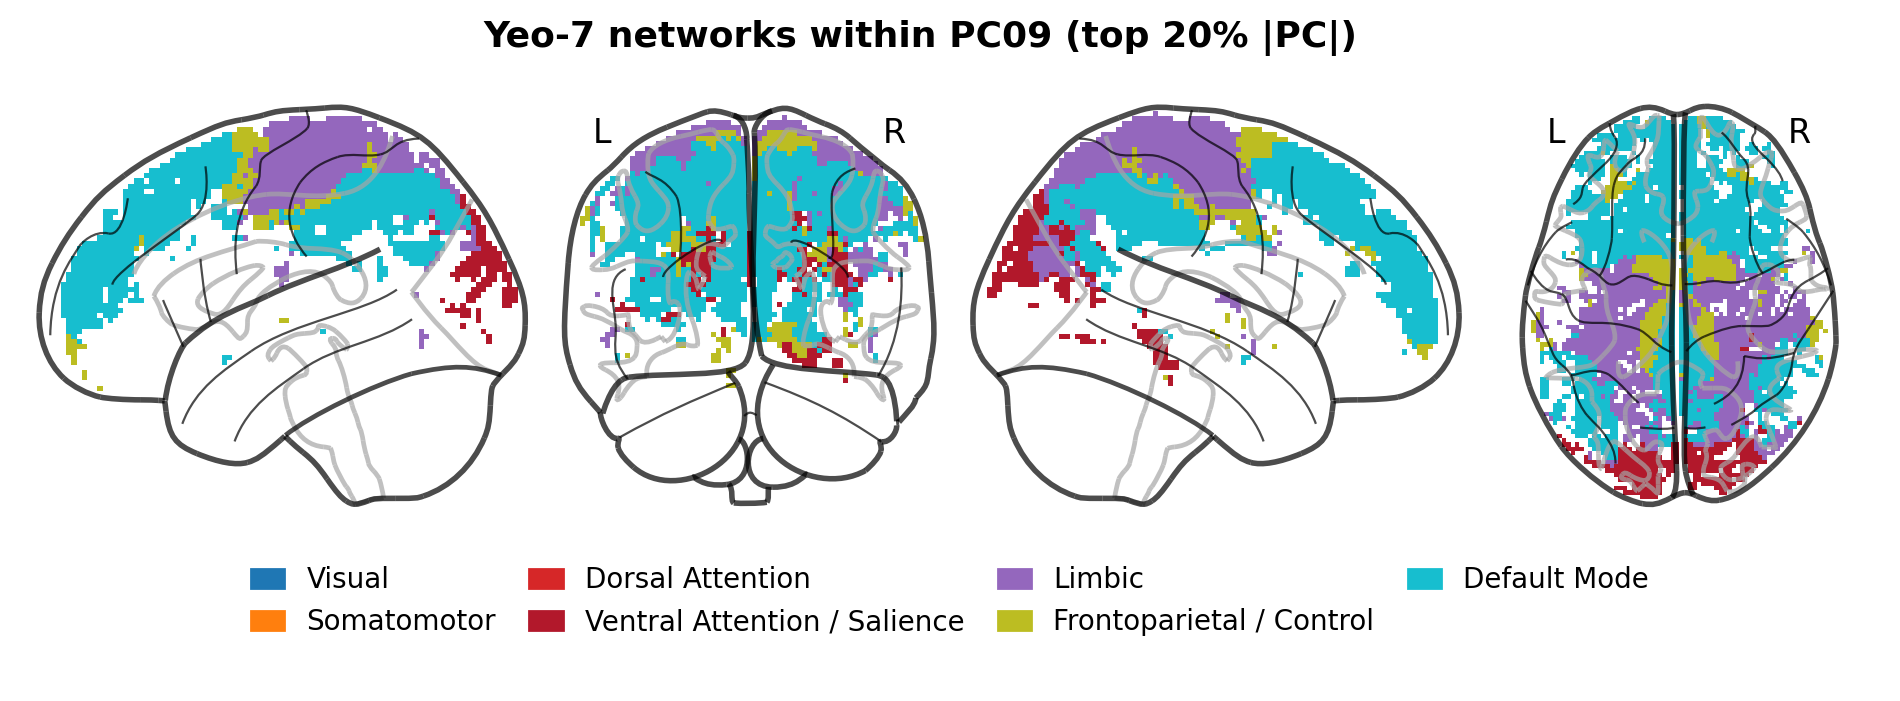

Saved overlay for PC09:
 - /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/paper_figures_partB_pca_yeo7/PC09_Yeo7Overlay_glass_TOP20pct_K20.png
 - /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/paper_figures_partB_pca_yeo7/PC09_Yeo7Overlay_glass_TOP20pct_K20.pdf


/var/folders/t5/2x7db7gn5cvcnqkt970hp7hc0000gn/T/ipykernel_28370/2724928100.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


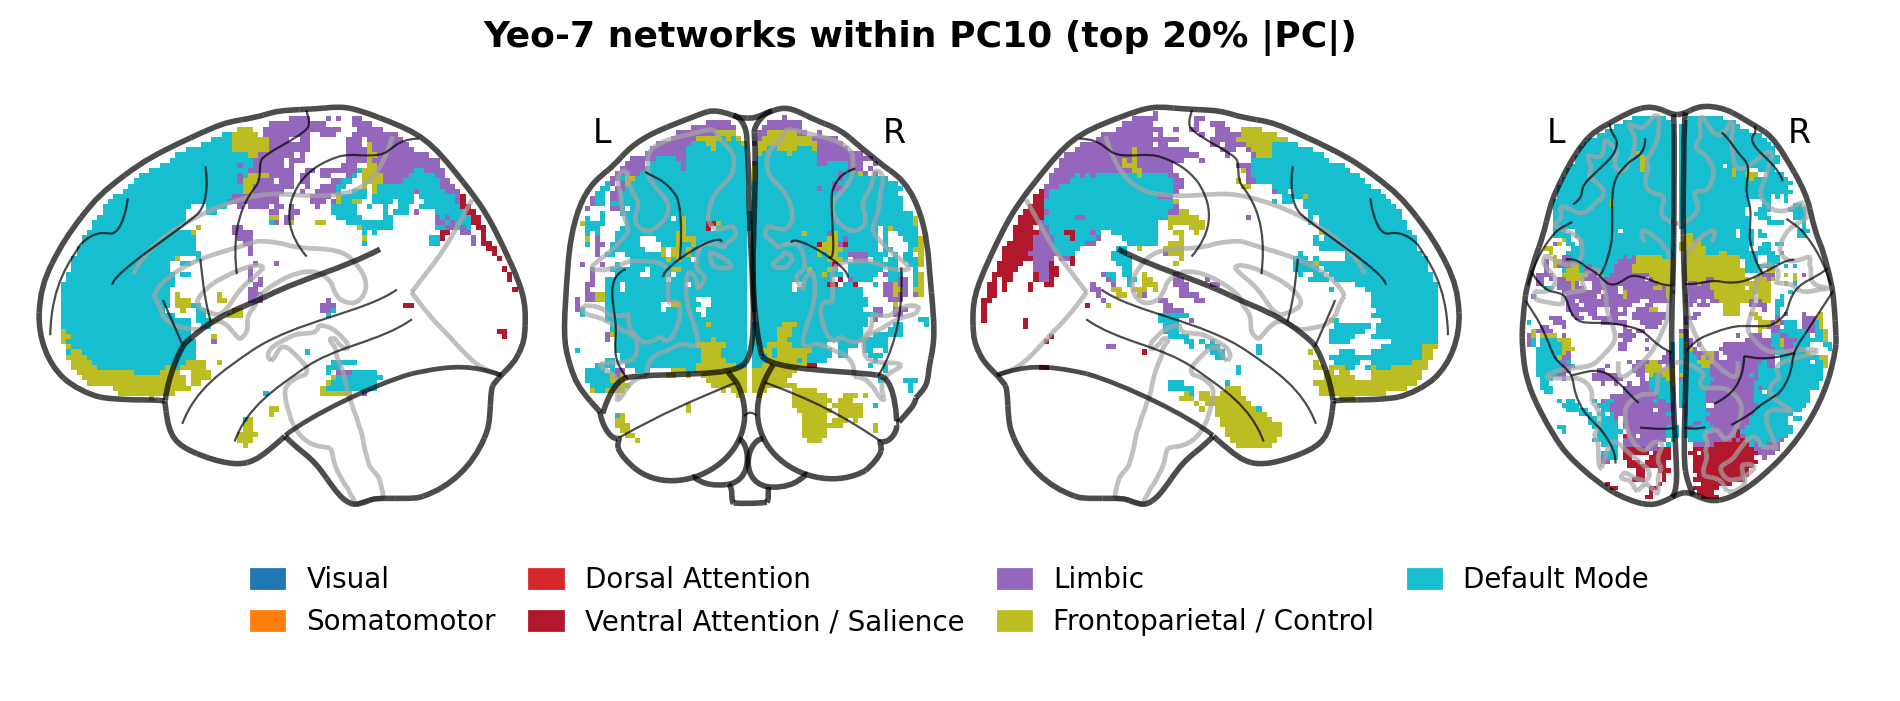

Saved overlay for PC10:
 - /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/paper_figures_partB_pca_yeo7/PC10_Yeo7Overlay_glass_TOP20pct_K20.png
 - /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/paper_figures_partB_pca_yeo7/PC10_Yeo7Overlay_glass_TOP20pct_K20.pdf


/var/folders/t5/2x7db7gn5cvcnqkt970hp7hc0000gn/T/ipykernel_28370/2724928100.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


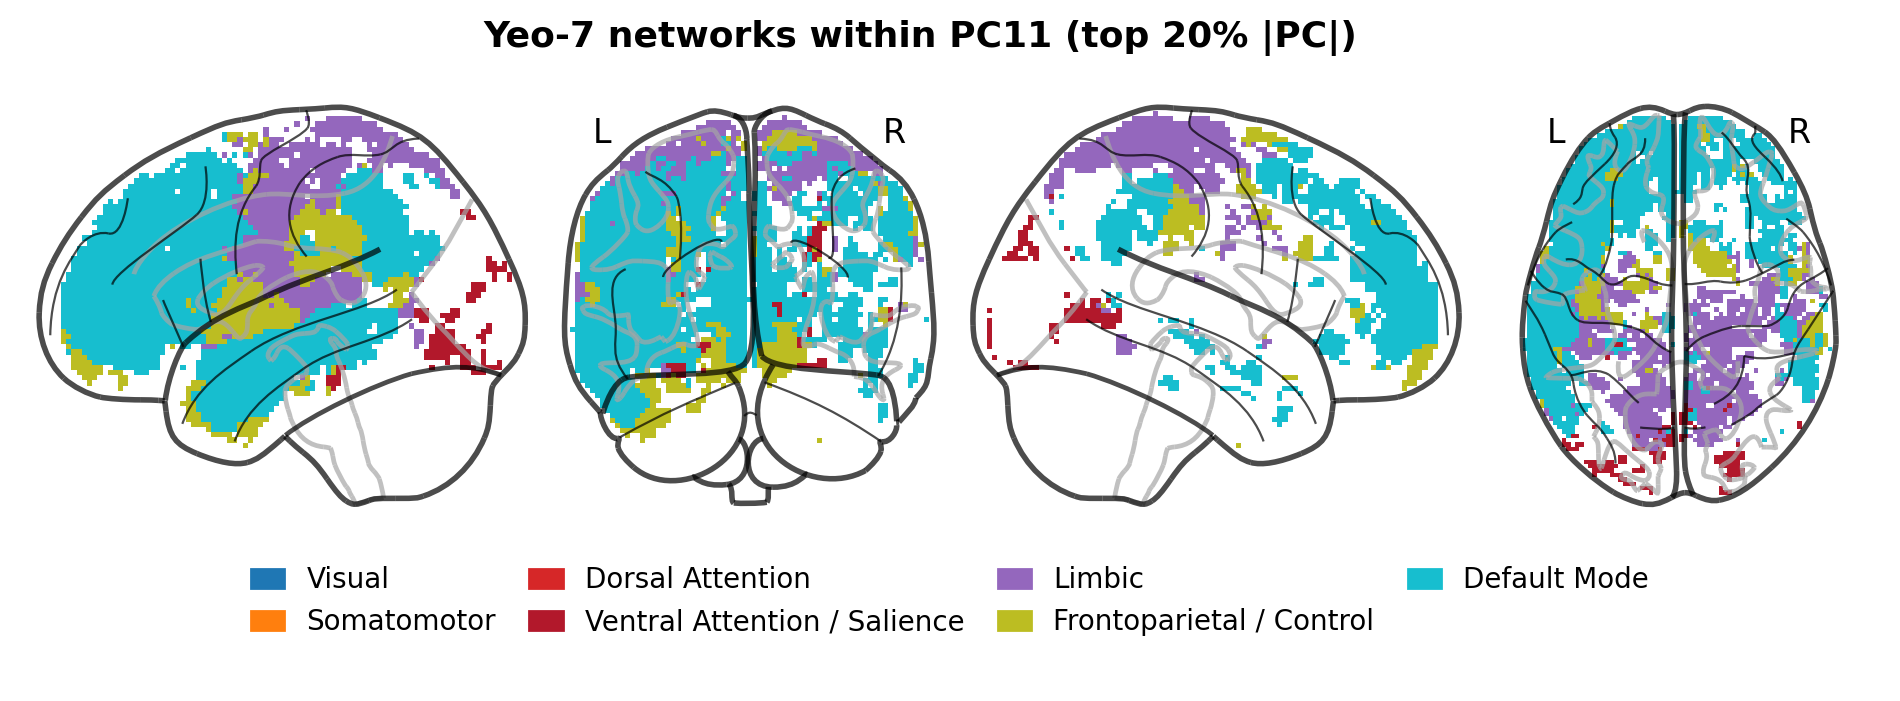

Saved overlay for PC11:
 - /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/paper_figures_partB_pca_yeo7/PC11_Yeo7Overlay_glass_TOP20pct_K20.png
 - /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/paper_figures_partB_pca_yeo7/PC11_Yeo7Overlay_glass_TOP20pct_K20.pdf
Saved overlap CSV: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/paper_figures_partB_pca_yeo7/Yeo7_overlap_top4PCs_TOP20pct_K20.csv


network_name,Default Mode,Dorsal Attention,Frontoparietal / Control,Limbic,Somatomotor,Ventral Attention / Salience,Visual
pc,,,,,,,
PC07,12.65,3.91,8.08,1.66,5.72,3.77,2.03
PC09,7.63,5.67,5.58,0.32,8.57,3.33,2.16
PC10,19.17,4.91,9.81,3.70,1.82,2.78,1.07
PC11,14.71,3.63,7.58,2.20,7.41,4.78,0.75


In [6]:
# Standalone Yeo-7 atlas figure
fig = plt.figure(figsize=(10, 3.5), dpi=200)
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1.0, 0.35], hspace=0.02)

ax_plot = fig.add_subplot(gs[0, 0])
plotting.plot_glass_brain(
    yeo7_mni_img,
    display_mode="lyrz",
    cmap=cmap_yeo,
    black_bg=False,
    colorbar=False,
    axes=ax_plot,
    title=None,
)
ax_plot.set_axis_off()

ax_leg = fig.add_subplot(gs[1, 0])
add_legend_row(ax_leg, handles, ncol=4, fontsize=10)

fig.text(
    0.5,
    0.98,
    "Yeo-7 atlas (7 networks)",
    ha="center",
    va="top",
    fontsize=13,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.95])

yeo_png = OUTDIR / "Yeo7_atlas_glass_customColors.png"
yeo_pdf = OUTDIR / "Yeo7_atlas_glass_customColors.pdf"
fig.savefig(yeo_png, dpi=DPI, bbox_inches="tight", facecolor="white")
fig.savefig(yeo_pdf, dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved Yeo atlas figure:")
print(" -", yeo_png)
print(" -", yeo_pdf)

# Component-specific overlays and overlap table
all_overlap_tables = []

for pc1, abs_thr_img in zip(TOP_PCS_1BASED, abs_thr_imgs):
    pc_label = f"PC{pc1:02d}"

    active_mask, _ = active_mask_from_abs_thr(abs_thr_img, mask_eroded)
    overlay = np.zeros_like(yeo_data, dtype=np.int16)
    overlay[active_mask] = yeo_data[active_mask]
    overlay_img = new_img_like(mni, overlay)

    fig = plt.figure(figsize=(12, 3.8), dpi=200)
    gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1.0, 0.38], hspace=0.02)

    ax_plot = fig.add_subplot(gs[0, 0])
    plotting.plot_glass_brain(
        overlay_img,
        display_mode="lyrz",
        cmap=cmap_yeo,
        black_bg=False,
        colorbar=False,
        axes=ax_plot,
        title=None,
    )
    ax_plot.set_axis_off()

    ax_leg = fig.add_subplot(gs[1, 0])
    add_legend_row(ax_leg, handles, ncol=4, fontsize=10)

    fig.text(
        0.5,
        0.98,
        f"Yeo-7 networks within {pc_label} (top {KEEP_TOP_PCT:.0f}% |PC|)",
        ha="center",
        va="top",
        fontsize=13,
        fontweight="bold",
    )
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    out_png = OUTDIR / f"{pc_label}_Yeo7Overlay_glass_TOP{int(KEEP_TOP_PCT)}pct_K{K}.png"
    out_pdf = OUTDIR / f"{pc_label}_Yeo7Overlay_glass_TOP{int(KEEP_TOP_PCT)}pct_K{K}.pdf"
    fig.savefig(out_png, dpi=DPI, bbox_inches="tight", facecolor="white")
    fig.savefig(out_pdf, dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()

    print(f"Saved overlay for {pc_label}:")
    print(" -", out_png)
    print(" -", out_pdf)

    overlap_df_pc = yeo7_overlap_table_for_pc(
        abs_thr_img=abs_thr_img,
        mask_bool=mask_eroded,
        yeo_labels=yeo_data,
        pc_label=pc_label,
        thr_abs_used=thresholds_used[pc1],
        keep_top_pct=KEEP_TOP_PCT,
        yeo_names=YEO7_NAMES,
    )
    all_overlap_tables.append(overlap_df_pc)

overlap_df = pd.concat(all_overlap_tables, ignore_index=True)
overlap_csv = OUTDIR / f"Yeo7_overlap_top4PCs_TOP{int(KEEP_TOP_PCT)}pct_K{K}.csv"
overlap_df.to_csv(overlap_csv, index=False)
print("Saved overlap CSV:", overlap_csv)

display(
    overlap_df
    .pivot(index="pc", columns="network_name", values="percent_abs_weight")
    .fillna(0.0)
    .round(2)
)


## 7. Optional notes for interpretation

- `percent_abs_weight` tells you how much of the thresholded absolute component weight falls in each Yeo network.
- `percent_voxels` tells you how many active voxels fall in each network.
- Because thresholding uses only the strongest values within the eroded brain mask, these summaries reflect the most prominent part of each component rather than the full unthresholded map.
